In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline 


In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)

32033

In [7]:
# build the voacabulary of characters and mapping to/from integers 
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [9]:
block_size = 3  # context length: how many characters do we take to predict the next one
X, Y = [], []

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]   # crop and append 
X = torch.tensor(X)
Y = torch.tensor(Y)



In [11]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y
    
import random 
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

    

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [13]:
Xtr.shape, Xtr.dtype, Ytr.shape, Ytr.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [147]:
g = torch.Generator().manual_seed(2147483647) 
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30,200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [149]:
sum(p.nelement() for p in parameters) # no of parameters

11897

In [151]:
for p in parameters:
    p.requires_grad = True

In [153]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [155]:
lri = []
lossi =[]
stepi = []

In [157]:

for i in range(200000):

    # minibatch construct 
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass 
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 +b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    
    # backward pass 
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update 
    #lr = lrs[i]
    lr = 0.01 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad 

    # track 
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
    
print(loss.item())

2.665761709213257


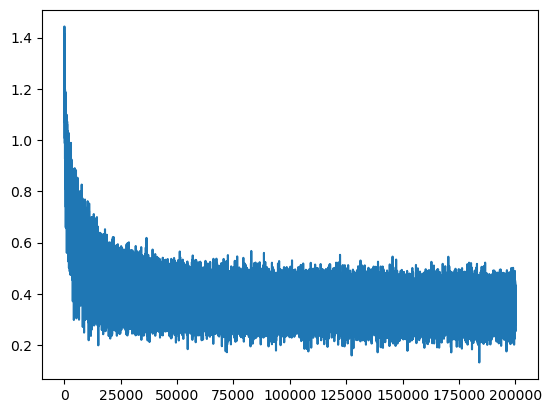

In [159]:
#plt.plot(lri, lossi)
#plt.show()
plt.plot(stepi,lossi)
plt.show()

In [161]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 +b1)

logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2747, grad_fn=<NllLossBackward0>)

In [163]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 +b1)

logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2857, grad_fn=<NllLossBackward0>)

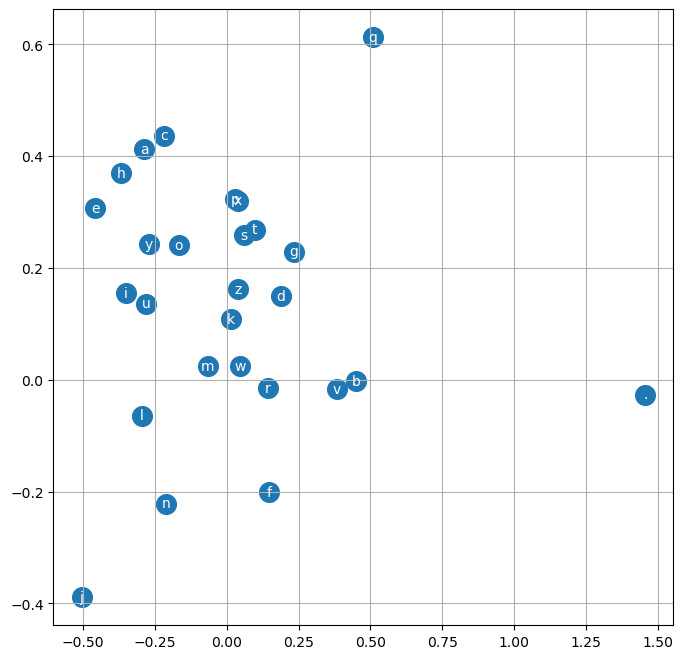

In [145]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')
plt.show()